# Garbe-Kourou analysis
<!-- markdownlint-disable MD013 -->

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from src.datasources import grdc, glofas
from src.constants import *

In [3]:
station_name = "garbekourou"

In [4]:
# glofas.process_reanalysis(station_name=station_name)

In [5]:
df_rea = glofas.load_reanalysis(station_name=station_name)

In [6]:
df_rea

,time,dis24
0,1979-01-01,0.656250
1,1979-01-02,0.625000
2,1979-01-03,0.593750
3,1979-01-04,0.562500
4,1979-01-05,0.546875
...,...,...
16797,2024-12-27,0.054688
16798,2024-12-28,0.054688
16799,2024-12-29,0.046875
16800,2024-12-30,0.046875


In [7]:
df_gk = grdc.load_grdc(station_id=GARBEKOUROU_GRDC_ID)

In [8]:
df_niamey = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [9]:
df_niamey = df_niamey.rename(columns={"runoff_mean": "runoff_mean_niamey"})

In [10]:
df_niamey

,time,runoff_mean_niamey
0,1929-01-01,1691.160034
1,1929-01-02,NaN
2,1929-01-03,NaN
3,1929-01-04,NaN
4,1929-01-05,NaN
...,...,...
35227,2025-06-13,119.000000
35228,2025-06-14,115.000000
35229,2025-06-15,134.000000
35230,2025-06-16,165.000000


In [11]:
df_compare = df_rea.merge(df_gk, how="outer").merge(df_niamey, how="outer")

In [12]:
df_compare.corr()

,time,dis24,runoff_mean,runoff_mean_niamey
time,1.000000,0.046725,0.286741,-0.098341
dis24,0.046725,1.000000,0.713735,0.260342
runoff_mean,0.286741,0.713735,1.000000,0.181913
runoff_mean_niamey,-0.098341,0.260342,0.181913,1.000000


In [13]:
min_year = 1979

In [14]:
df_compare = df_compare[df_compare["time"].dt.year >= min_year]

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_60281/208947458.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 4))


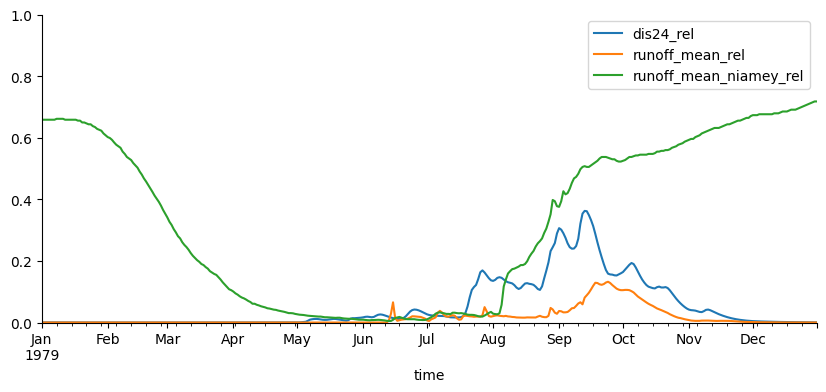

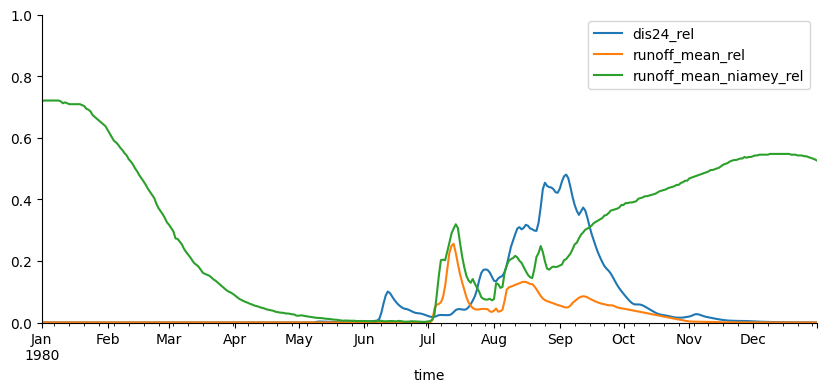

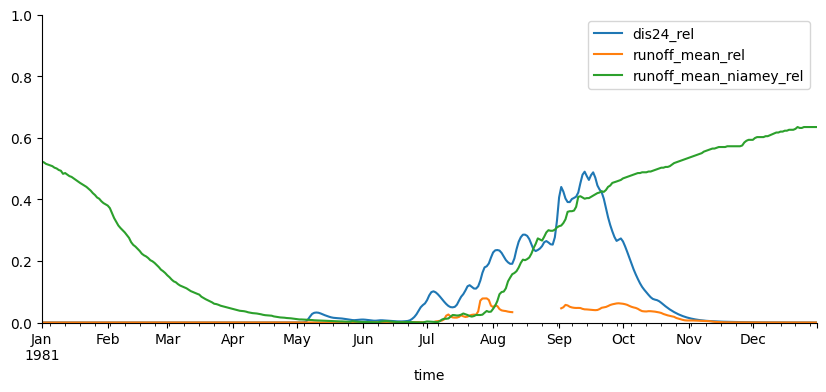

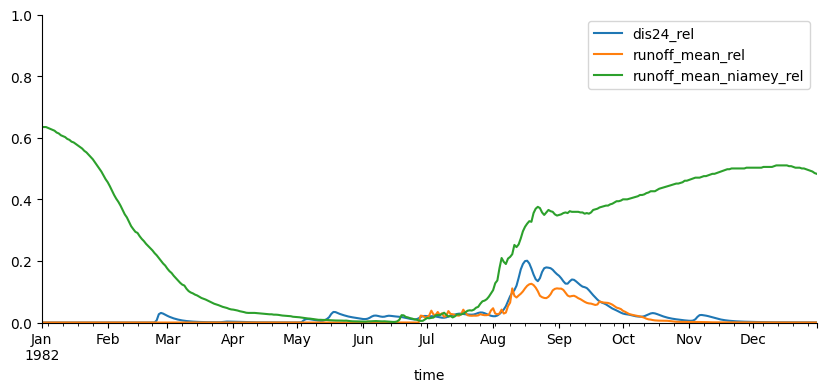

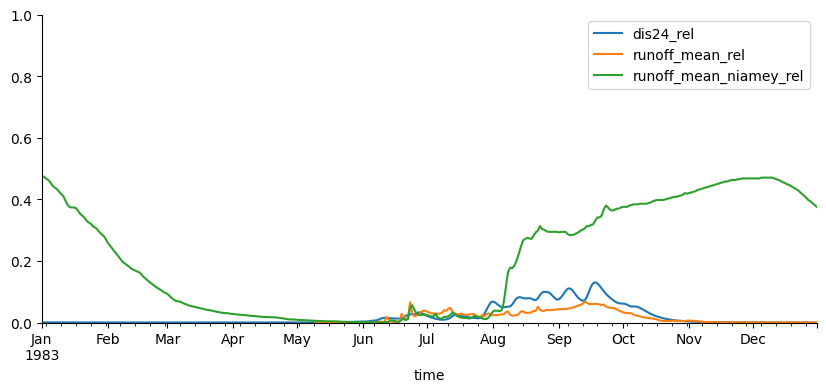

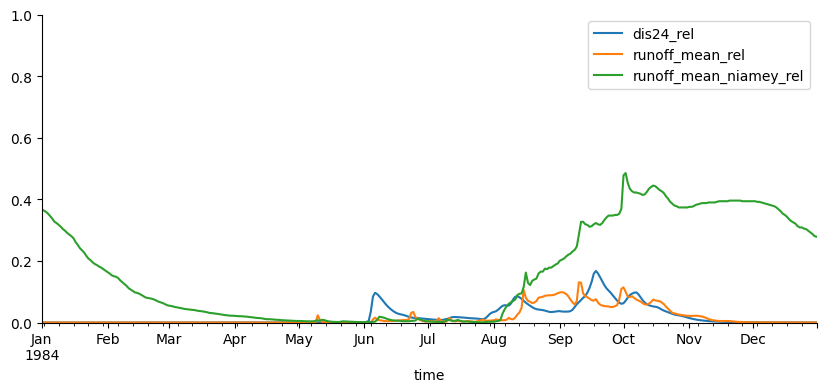

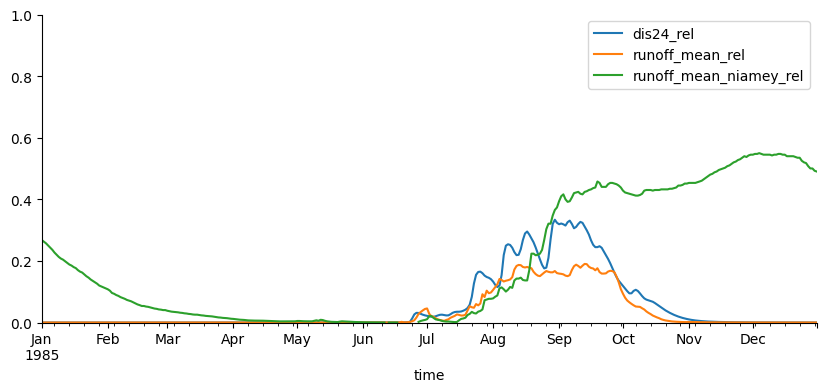

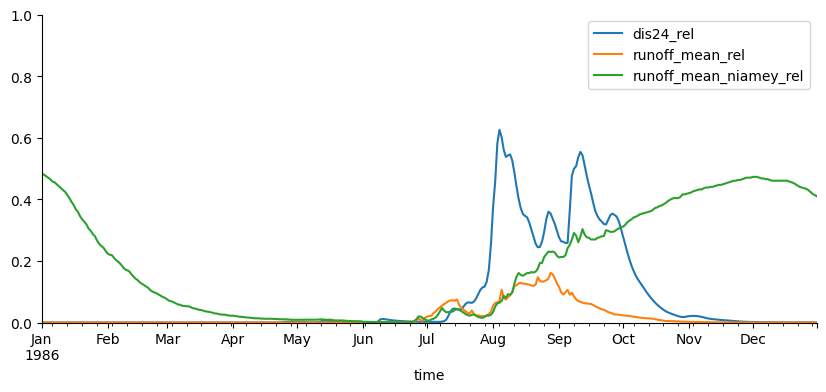

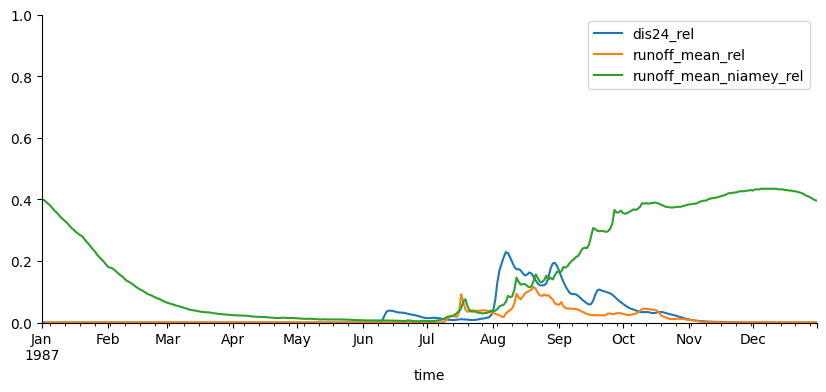

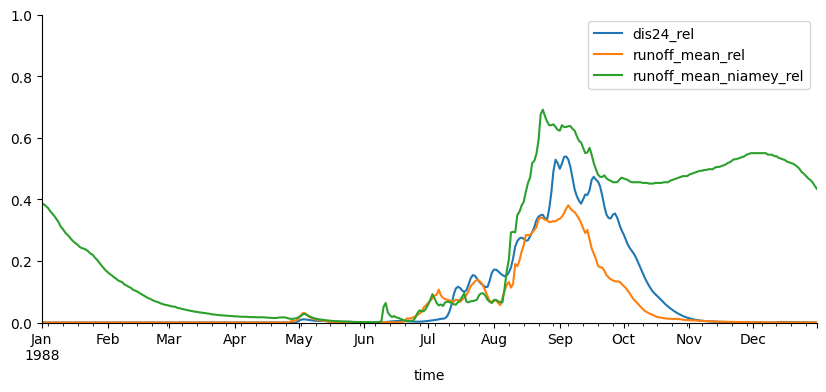

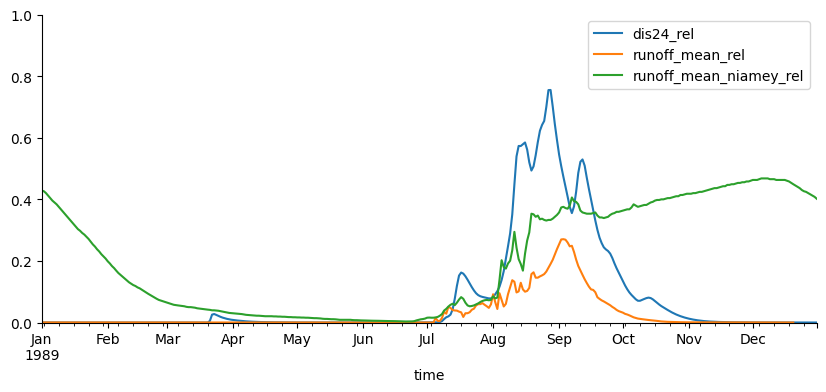

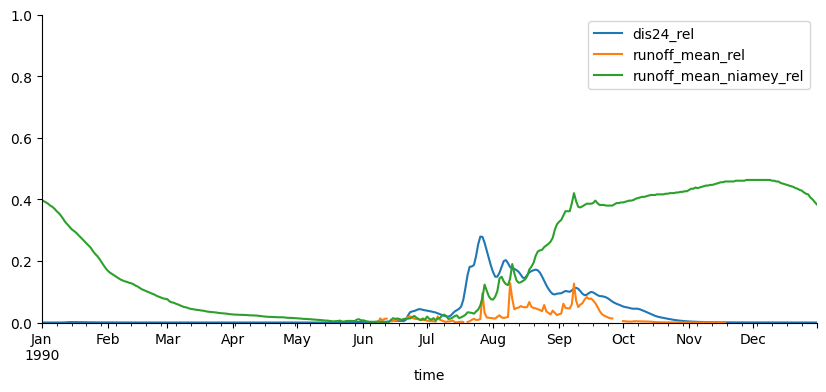

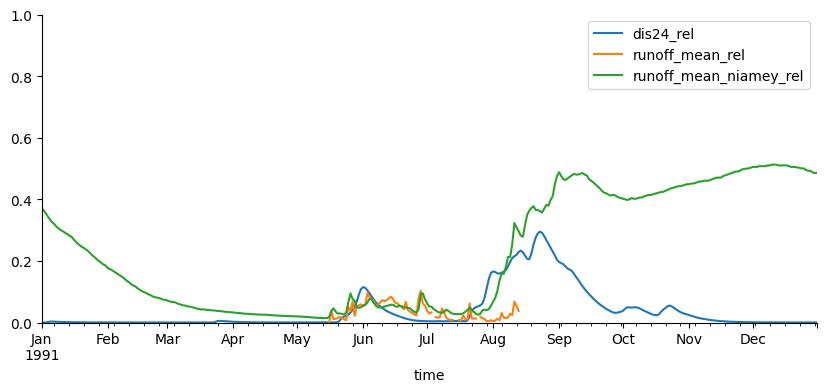

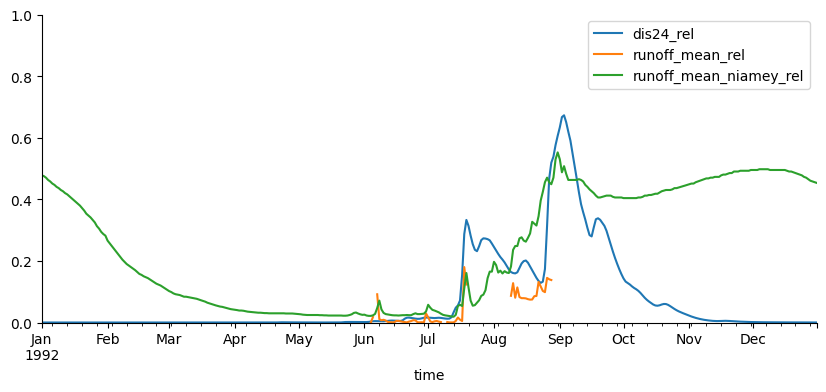

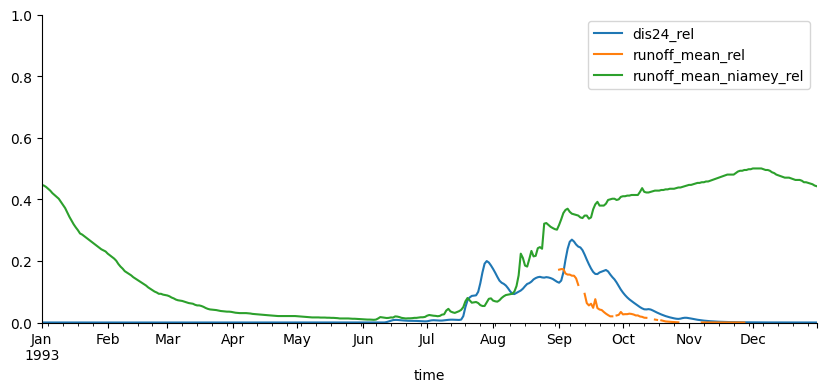

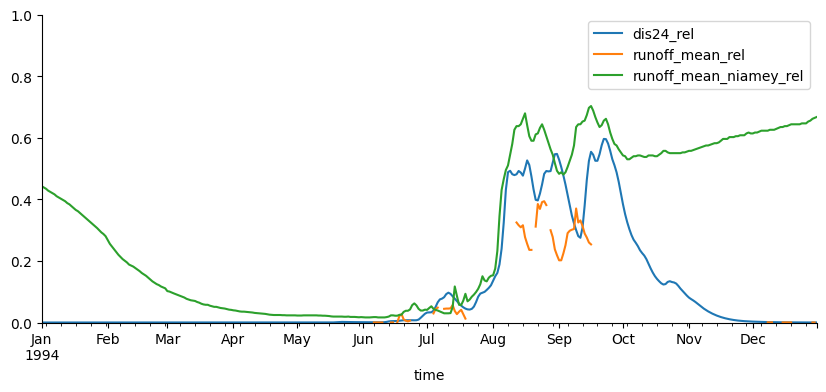

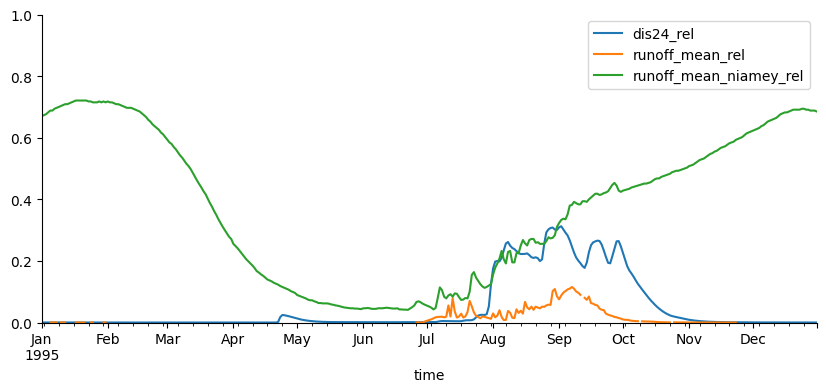

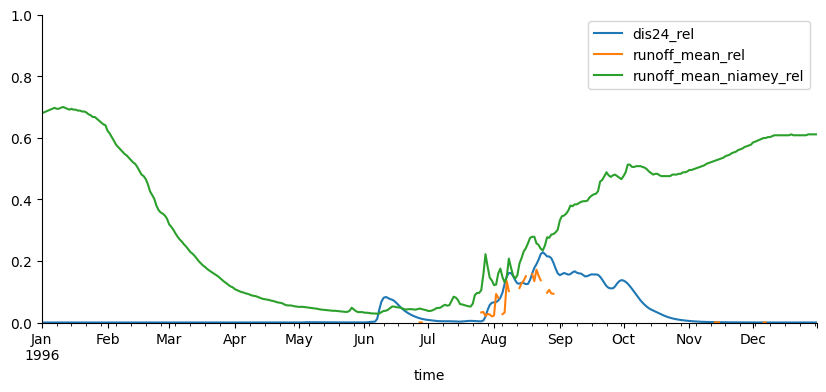

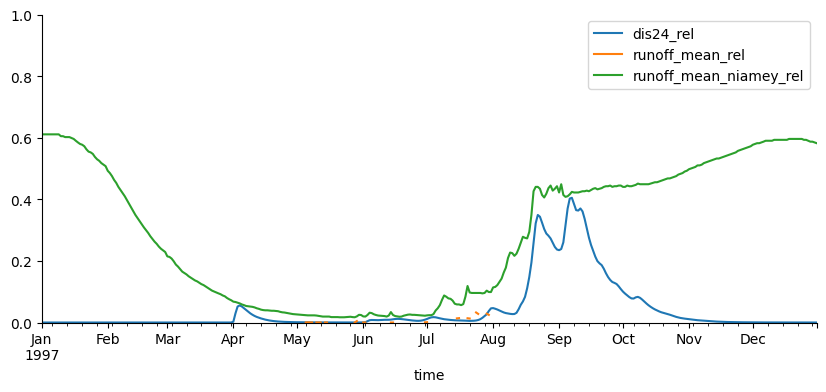

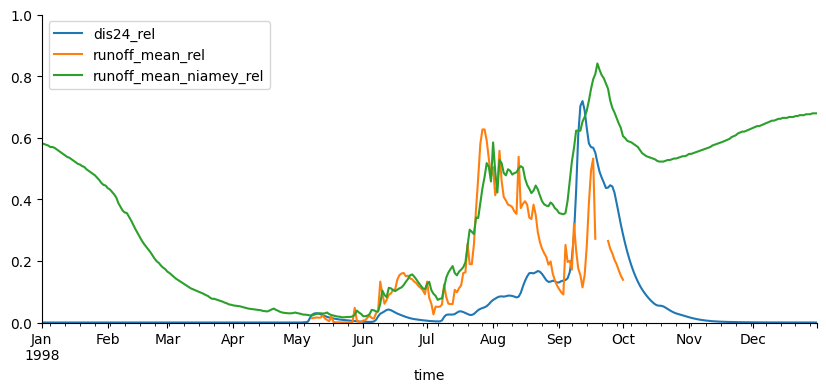

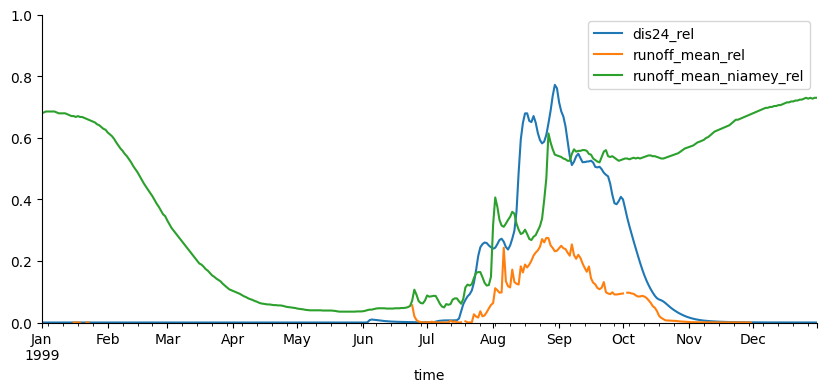

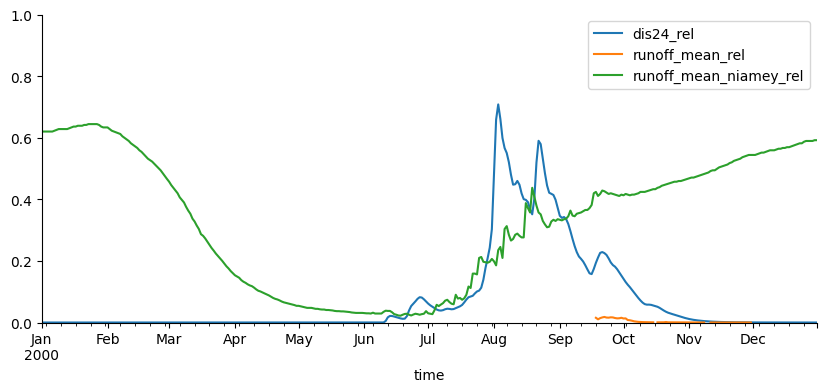

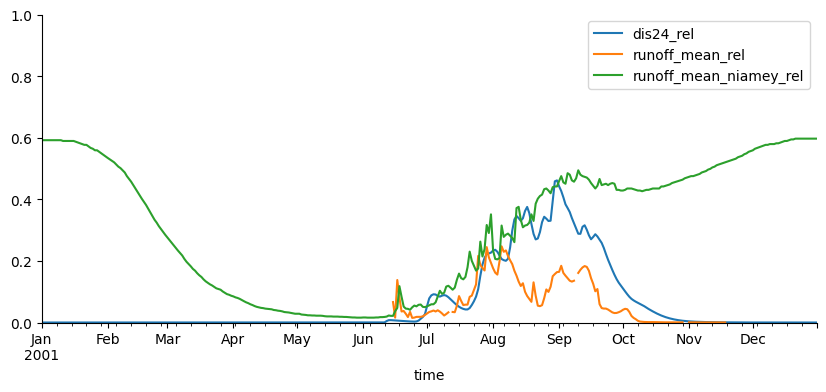

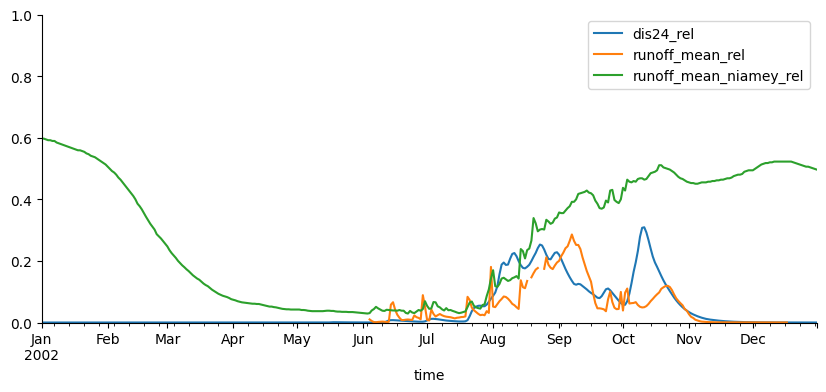

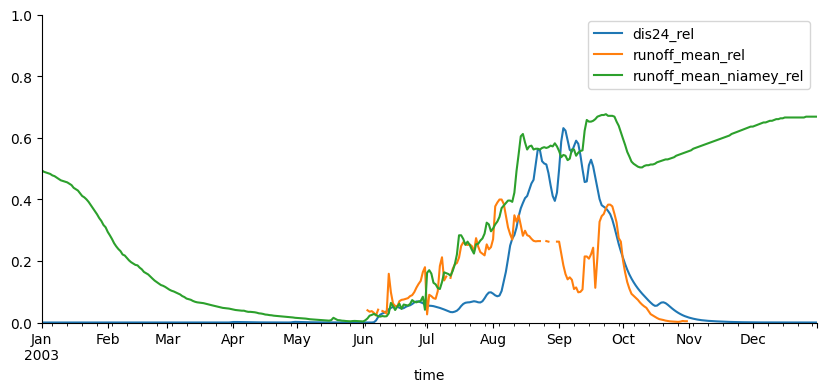

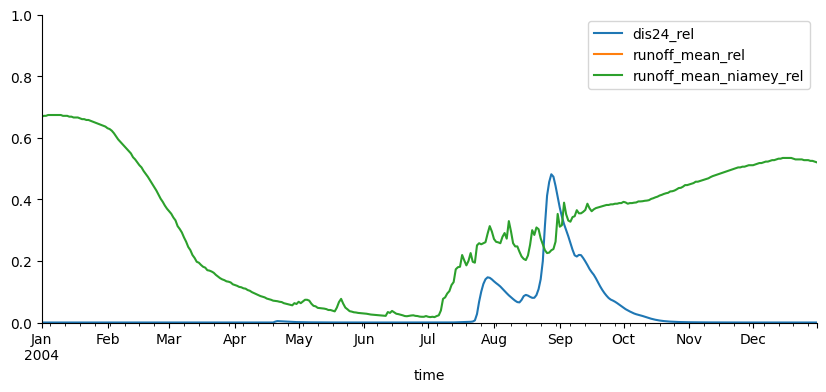

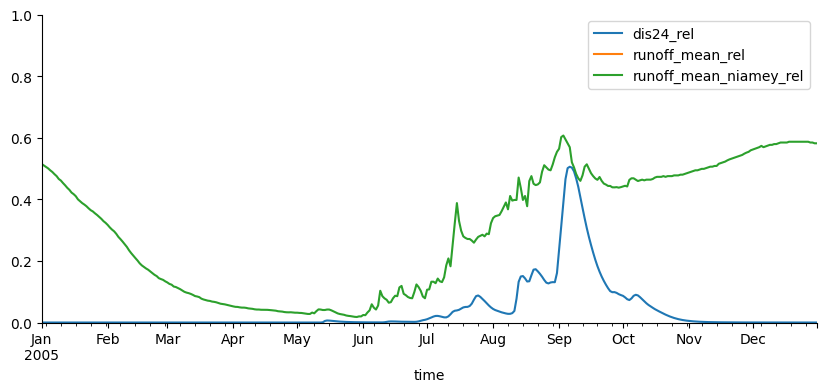

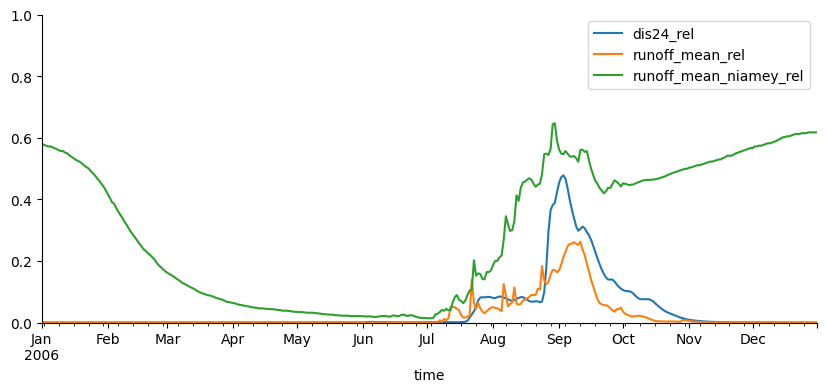

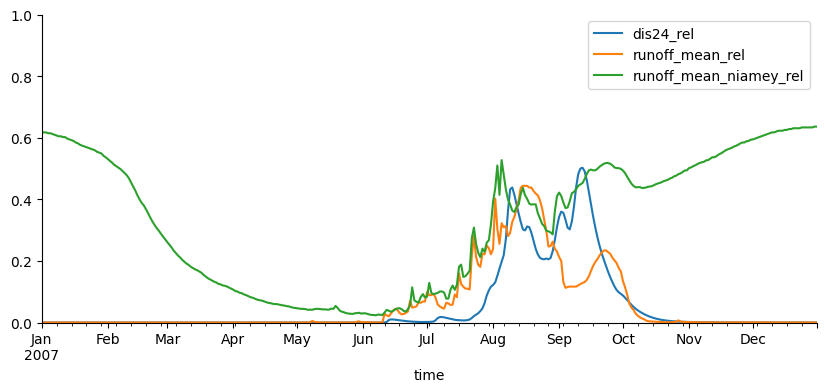

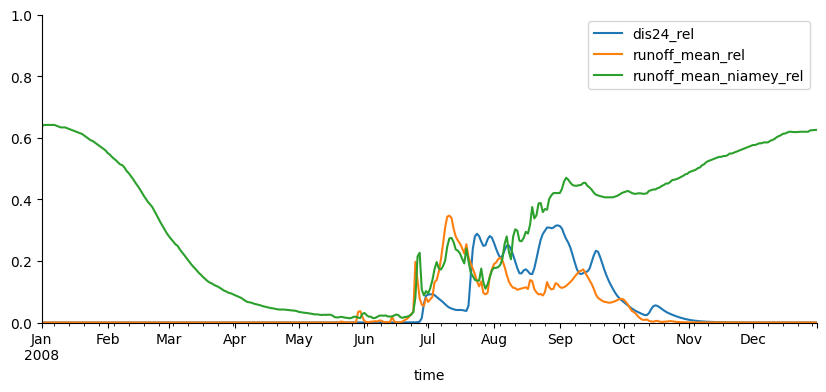

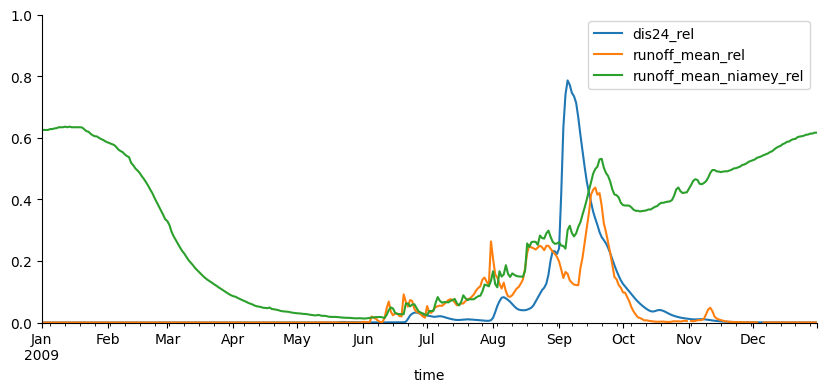

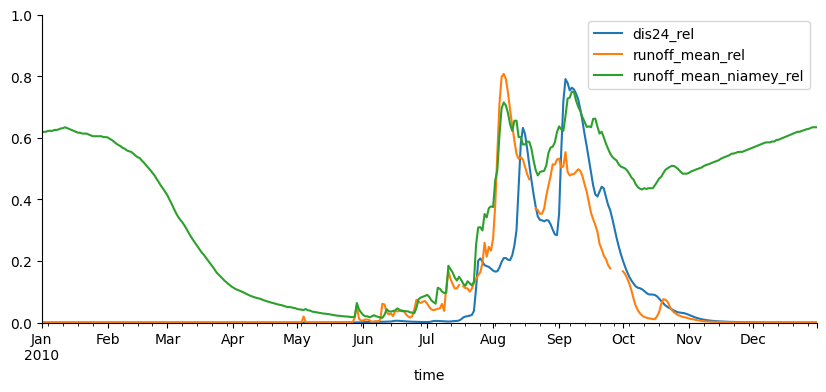

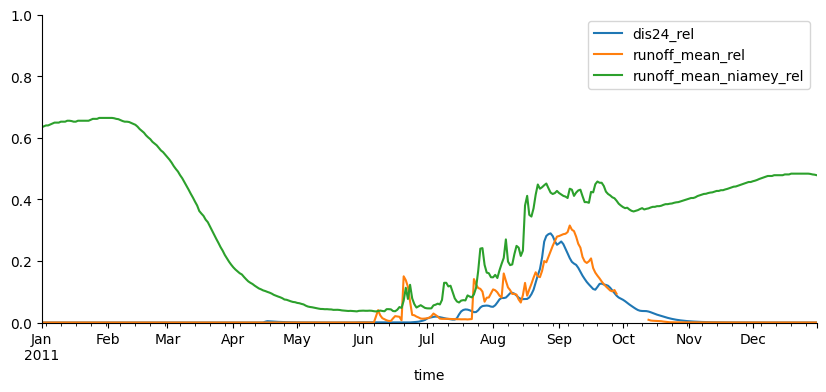

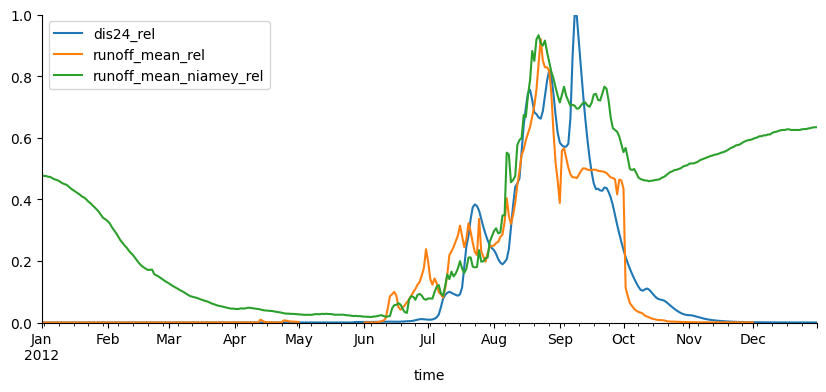

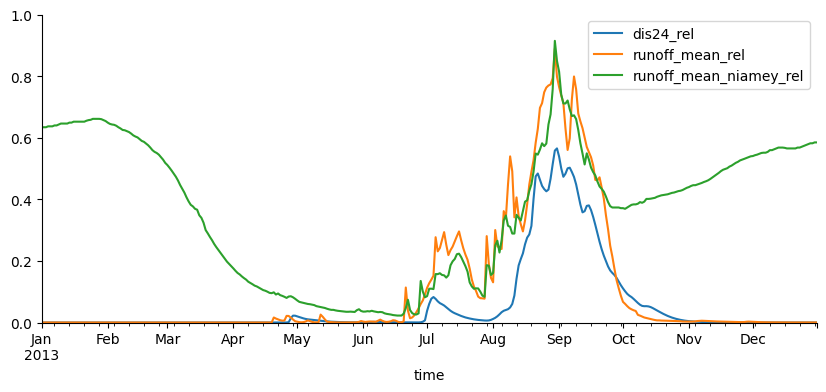

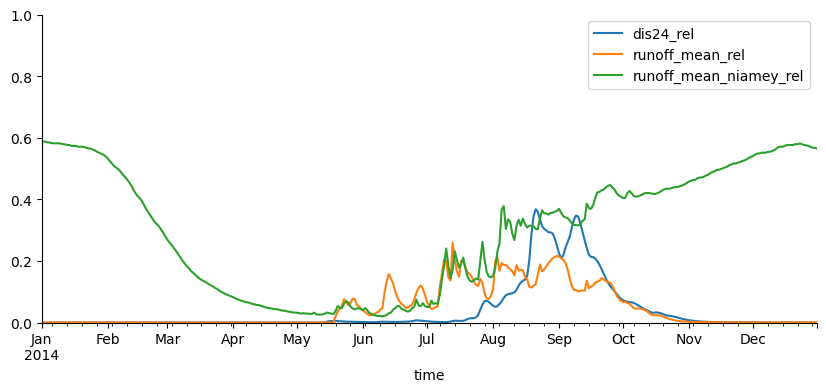

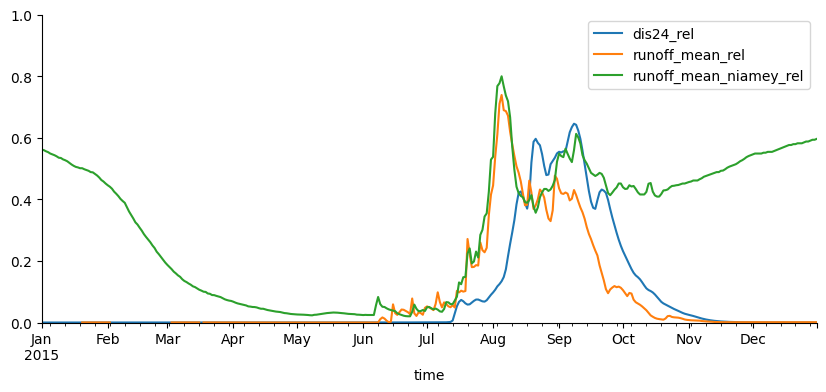

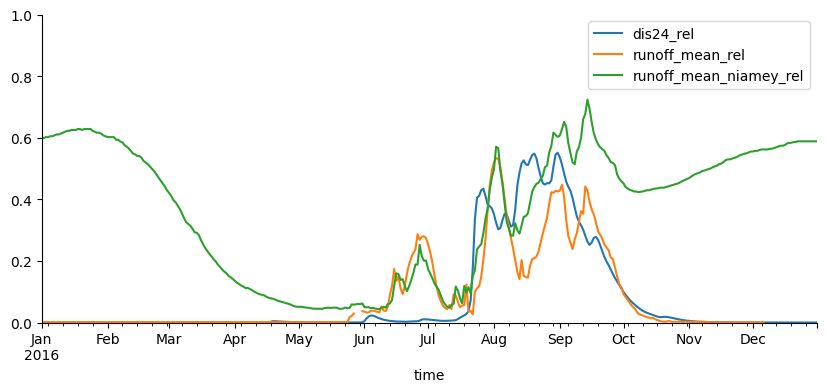

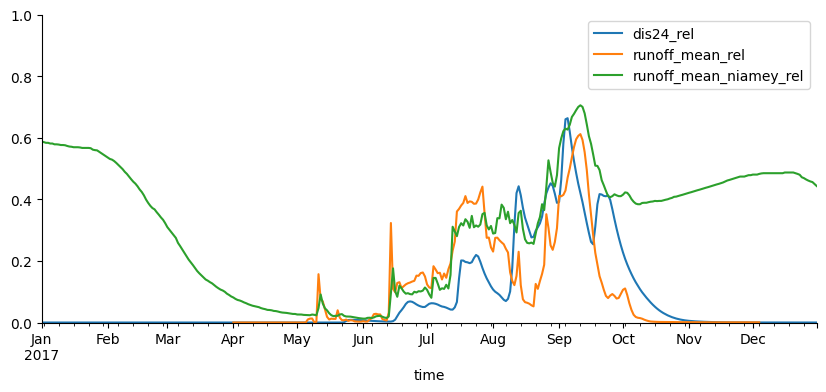

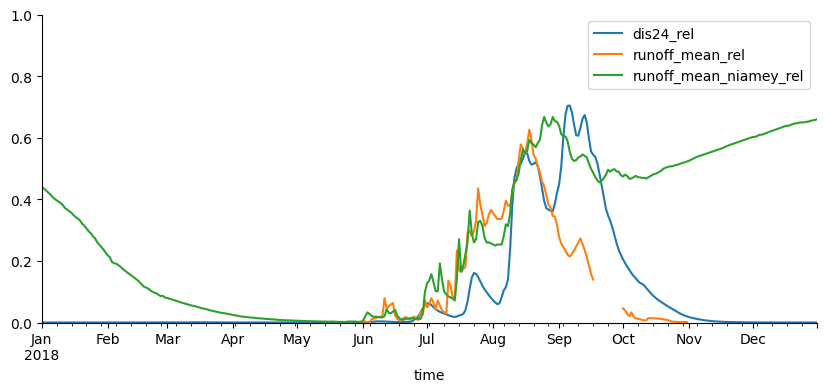

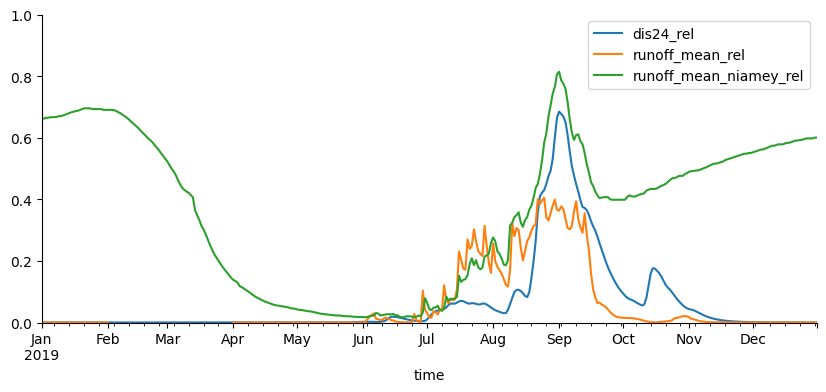

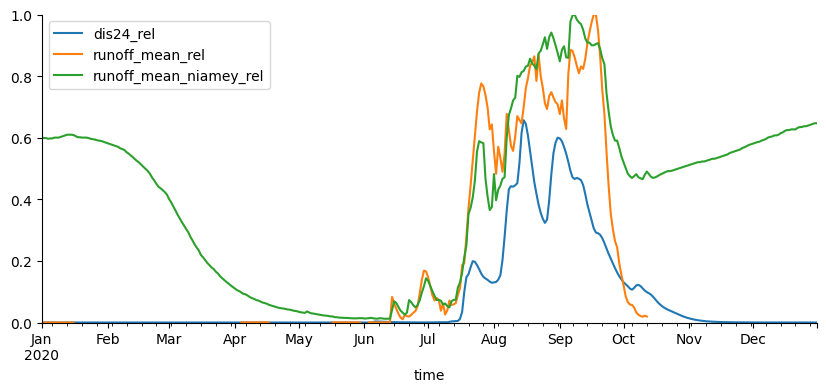

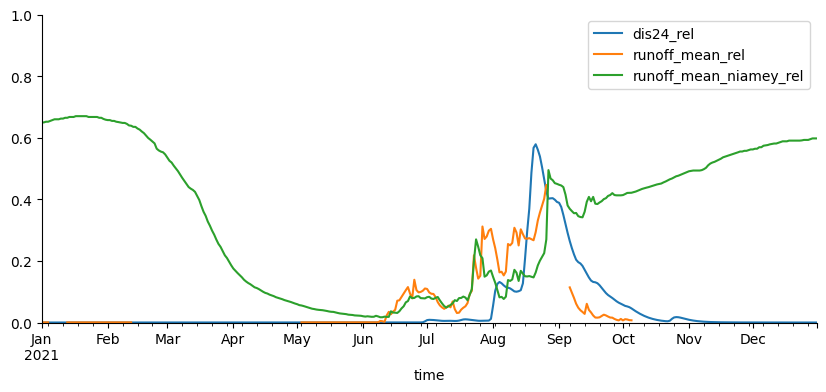

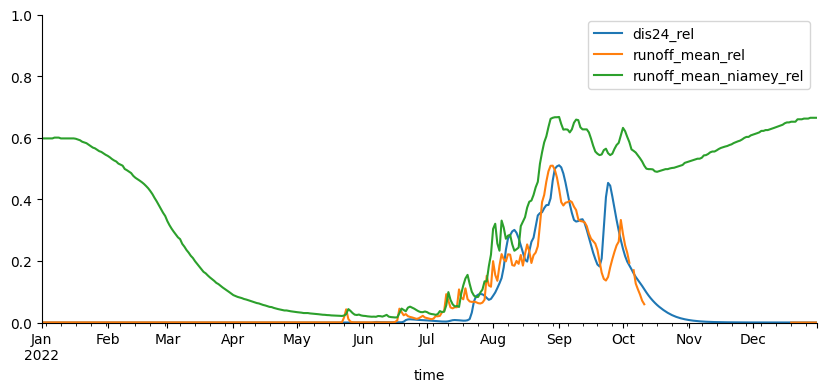

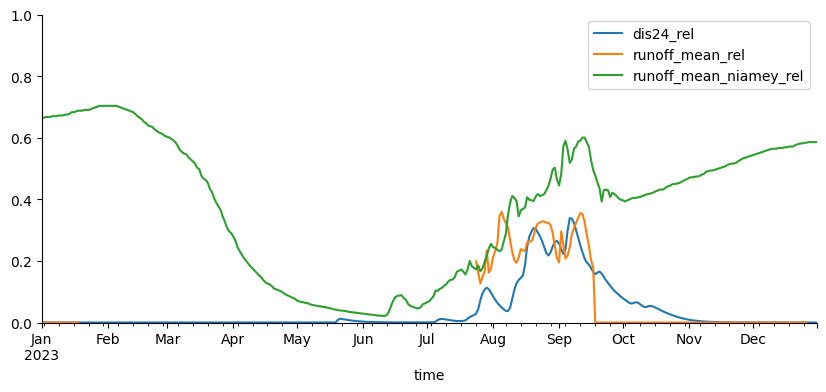

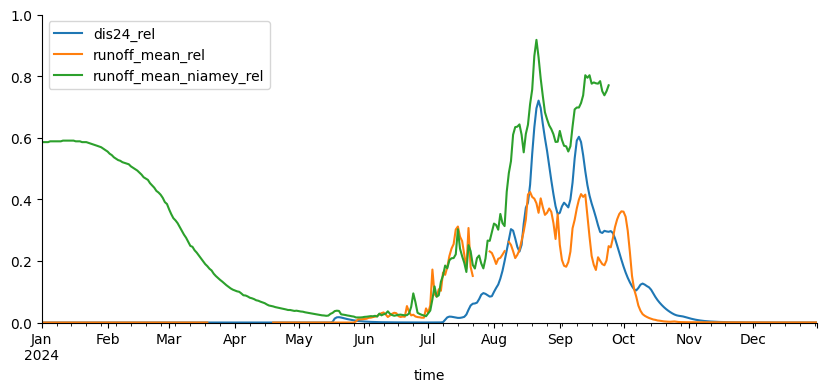

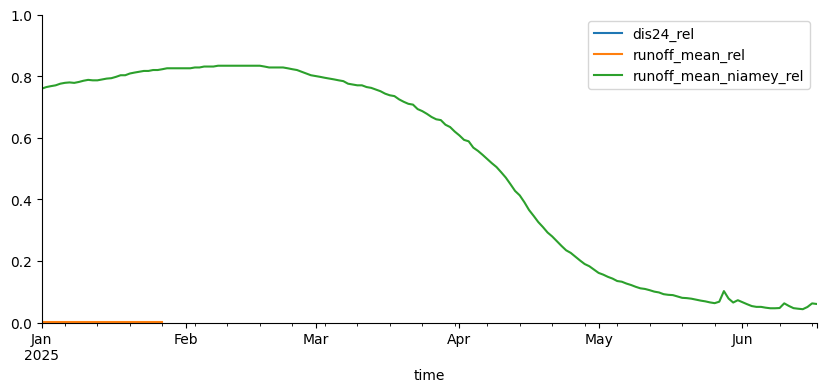

In [15]:
df_plot = df_compare.copy()
for x in ["dis24", "runoff_mean", "runoff_mean_niamey"]:
    df_plot[f"{x}_rel"] = df_plot[x] / df_plot[x].max()

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    fig, ax = plt.subplots(figsize=(10, 4))
    group.set_index("time").plot(ax=ax, y=[x for x in df_plot if "rel" in x])
    ax.set_ylim((0, 1))
    [ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [17]:
gk_drop_years = [
    1981,
    1991,
    1992,
    1993,
    1994,
    1996,
    1997,
    2000,
    2004,
    2005,
    2021,
]

In [18]:
df_peaks = (
    df_compare[df_compare["time"].dt.month < 11]
    .groupby(df_compare["time"].dt.year)
    .max()[["dis24", "runoff_mean", "runoff_mean_niamey"]]
    .reset_index(names="year")
)

In [19]:
df_peaks = df_peaks[
    (~df_peaks["year"].isin(gk_drop_years)) & (df_peaks["year"] < 2025)
]

In [20]:
df_peaks.corr()

,year,dis24,runoff_mean,runoff_mean_niamey
year,1.000000,0.458992,0.672570,0.611209
dis24,0.458992,1.000000,0.693044,0.563470
runoff_mean,0.672570,0.693044,1.000000,0.779355
runoff_mean_niamey,0.611209,0.563470,0.779355,1.000000


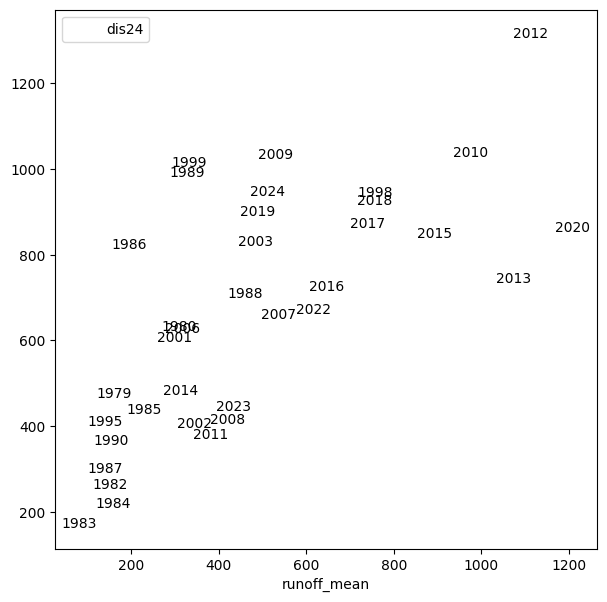

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))

df_peaks.plot(x="runoff_mean", y="dis24", ax=ax, linewidth=0)

for year, row in df_peaks.set_index("year").iterrows():
    ax.annotate(year, row[["runoff_mean", "dis24"]], va="center", ha="center")

In [22]:
df_compare

,time,dis24,runoff_mean,runoff_mean_niamey
18262,1979-01-01,0.656250,0.0,1749.22998
18263,1979-01-02,0.625000,0.0,1749.22998
18264,1979-01-03,0.593750,0.0,1749.22998
18265,1979-01-04,0.562500,0.0,1749.22998
18266,1979-01-05,0.546875,0.0,1749.22998
...,...,...,...,...
35227,2025-06-13,NaN,NaN,119.00000
35228,2025-06-14,NaN,NaN,115.00000
35229,2025-06-15,NaN,NaN,134.00000
35230,2025-06-16,NaN,NaN,165.00000


In [26]:
df_plot = df_compare.copy()
df_plot["plot_date"] = df_plot["time"].map(
    lambda x: pd.Timestamp(
        year=1904,
        month=x.month,
        day=x.day,
    )
)

[None, None]

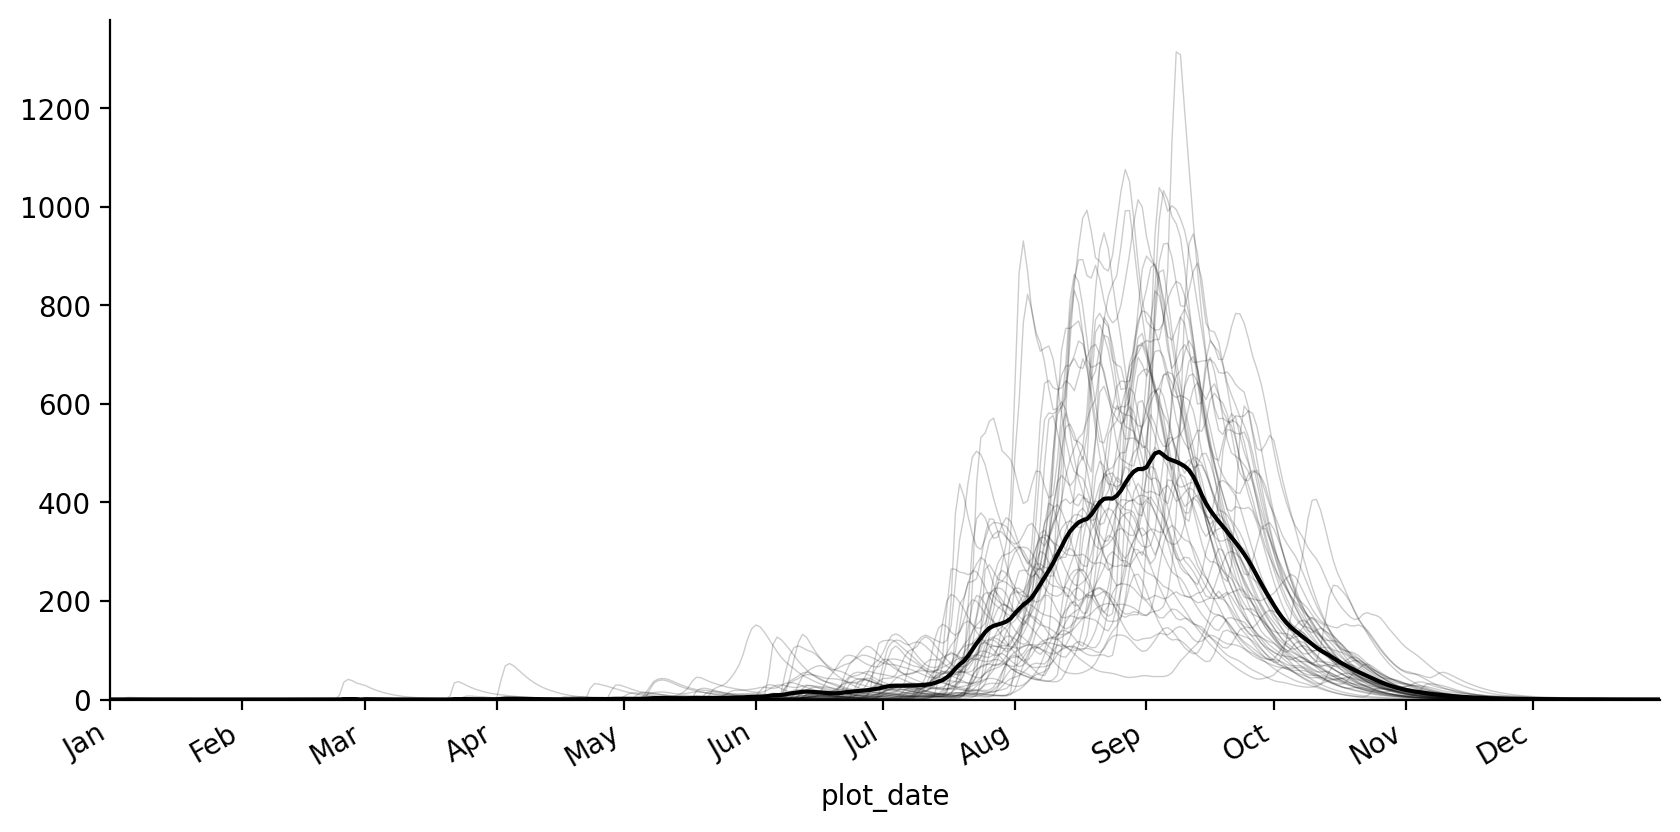

In [30]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    group.plot(
        x="plot_date",
        y="dis24",
        ax=ax,
        legend=False,
        color="k",
        alpha=0.2,
        linewidth=0.5,
    )

df_plot.groupby("plot_date")["dis24"].mean().plot(ax=ax, color="k")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(bottom=0)
ax.set_xlim((df_plot["plot_date"].min(), df_plot["plot_date"].max()))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]